In [1]:
import numpy as np
from functools import partial
from pathlib import Path
import sys
# Ensure the workspace root is on sys.path so local packages (like `utils`) are importable
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / 'utils').is_dir() or (parent / '.git').exists():
        project_root = str(parent)
        break
if project_root is None:
    project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.plotting import (
    compute_shap_values_loso,
    create_shap_summary_plot,
    handle_complex_numbers,
    load_feature_data_from_best_params,
    load_subject_data,
    spectral_index_to_name,
)

DATA_FOLDER = '/space/gzanardini/tuh_whole/split'

best_parameters = {
    'spectral': ('CAR', 20, 'std'),
    'cwt': ('BipolarDB', 60, 'std'),
    'dwt': ('Laplacian', 20, 'std'),
    'mst': ('BipolarDB', 10, 'skew'),
    'sst': ('CAR', 20, 'mean'),
    'cc': ('Cz', 60, 'median'),
    'plv': ('BipolarDB', 5, 'median'),
    'gcc': ('Laplacian', 5, 'mean'),
    'gplv': ('BipolarDB', 10, 'median'),
    'utm': ('CAR', 1, 'median'),
}

In [2]:
description, labels, subjects, unique_subjects, subject_labels = load_subject_data(DATA_FOLDER)
load_feature_data = partial(load_feature_data_from_best_params, DATA_FOLDER, best_parameters)

In [3]:
channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

spectral_feature_names = [spectral_index_to_name(i, channels=channels) for i in range(95)]

100%|██████████| 30/30 [00:05<00:00,  5.30it/s]


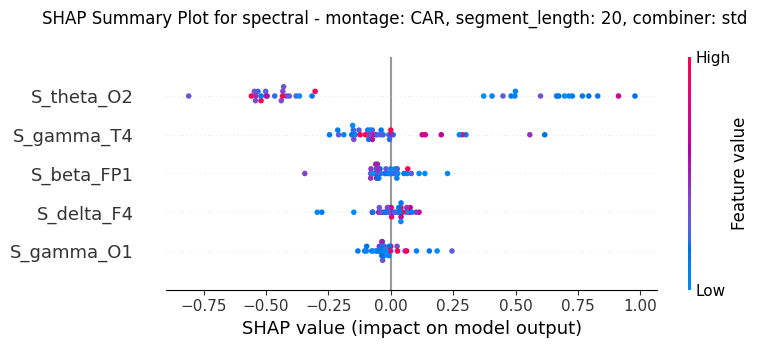

100%|██████████| 30/30 [00:07<00:00,  3.85it/s]


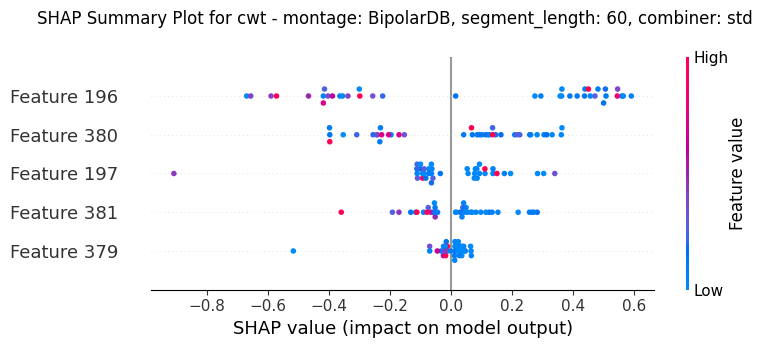

100%|██████████| 30/30 [00:06<00:00,  4.63it/s]


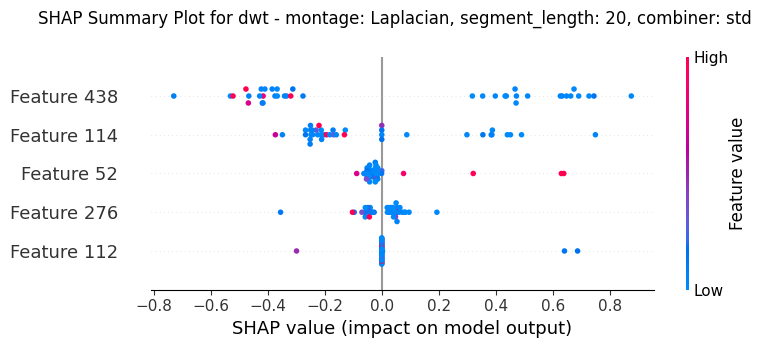

100%|██████████| 30/30 [00:04<00:00,  6.20it/s]


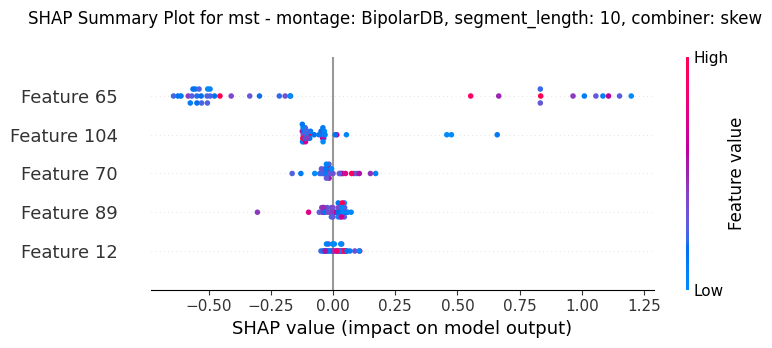

100%|██████████| 30/30 [00:05<00:00,  5.89it/s]


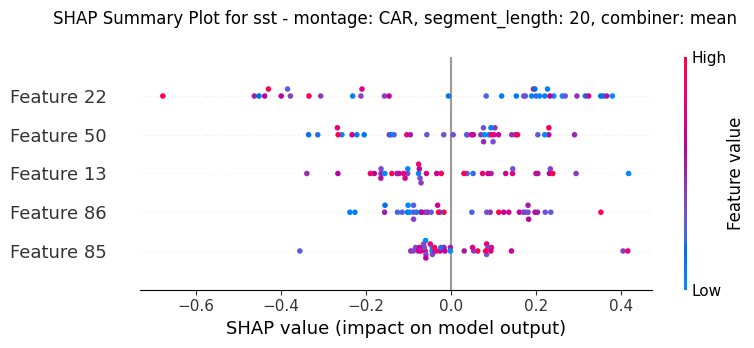

100%|██████████| 30/30 [00:05<00:00,  5.51it/s]


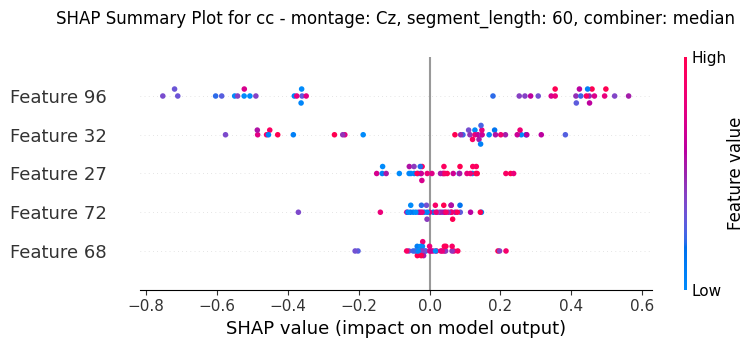

100%|██████████| 30/30 [00:08<00:00,  3.47it/s]


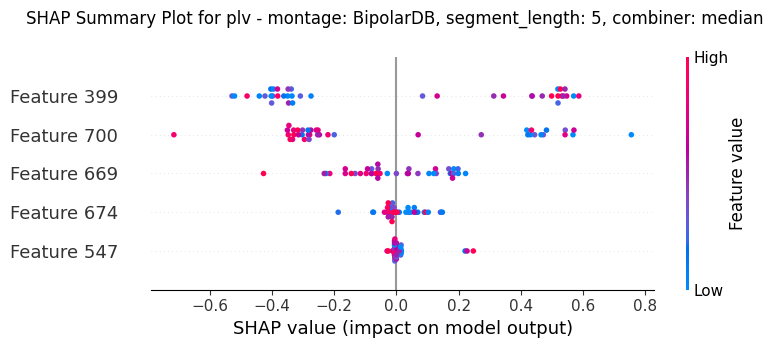

100%|██████████| 30/30 [00:04<00:00,  6.44it/s]


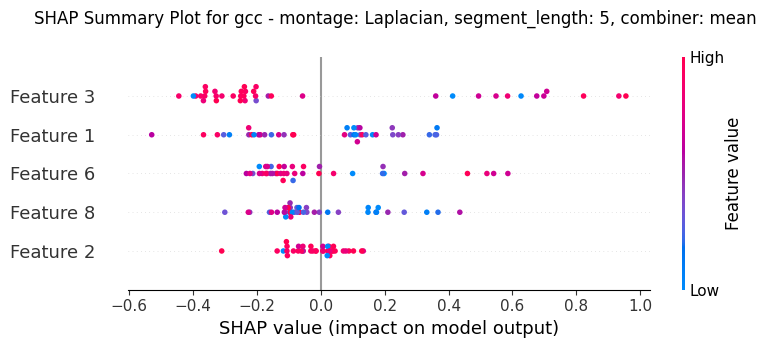

100%|██████████| 30/30 [00:04<00:00,  7.46it/s]


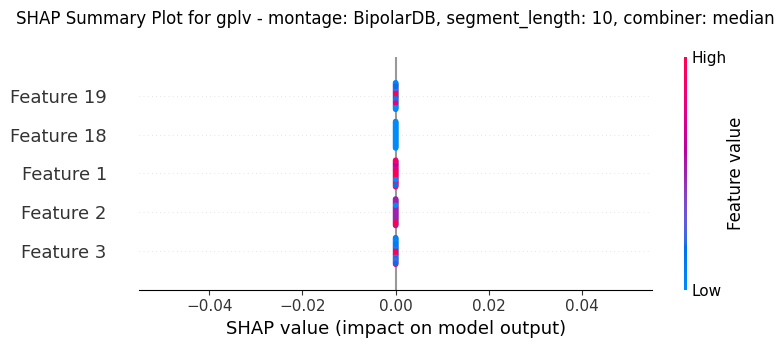

100%|██████████| 30/30 [00:05<00:00,  5.89it/s]


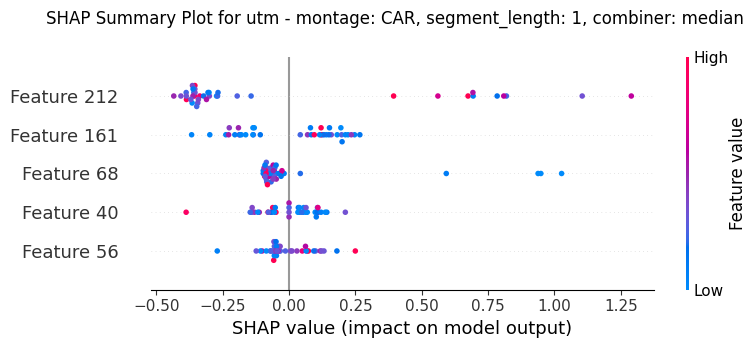

In [4]:
# For each feature, compute SHAP while excluding known problematic subjects.
for feature_name in best_parameters.keys():
    data, montage, segment_length, combiner = load_feature_data(feature_name)
    data = handle_complex_numbers(data)

    exclude_subjects = np.array(['aaaaajgj', 'aaaaakcd '])
    keep_mask = ~np.isin(subjects, exclude_subjects)

    filtered_data = data[keep_mask]
    filtered_labels = labels[keep_mask]
    filtered_subjects = subjects[keep_mask]
    filtered_unique_subjects = unique_subjects[~np.isin(unique_subjects, exclude_subjects)]

    shap_values_folds = compute_shap_values_loso(
        filtered_data,
        filtered_labels,
        filtered_subjects,
        filtered_unique_subjects,
    )

    custom_names = spectral_feature_names if feature_name == 'spectral' else None

    save_path = None
    if feature_name == 'spectral':
        save_path = f'shap_summary_{feature_name}_tuh_without_ieds.pdf'

    create_shap_summary_plot(
        shap_values=shap_values_folds,
        data=filtered_data,
        feature_name=feature_name,
        montage=montage,
        segment_length=segment_length,
        combiner=combiner,
        max_display=5,
        custom_feature_names=custom_names,
        save_path=save_path,
    )